# Reproducing Kernel Hilbert Spaces & Kernel Methods
## From Functional Analysis Foundations to Two-Sample Testing and RKHS Optimization

---

## 1. Reproducing Kernel Hilbert Spaces

### 1.1 Definition

A **Reproducing Kernel Hilbert Space (RKHS)** $\mathcal{H}$ over a set $\mathcal{X}$ is a Hilbert space of functions $f : \mathcal{X} \to \mathbb{R}$ such that for every $x \in \mathcal{X}$, the **evaluation functional** $\delta_x : \mathcal{H} \to \mathbb{R}$ defined by

$$\delta_x(f) = f(x)$$

is **continuous** (equivalently, bounded). That is, for each $x \in \mathcal{X}$, there exists a constant $C_x > 0$ such that

$$|f(x)| = |\delta_x(f)| \leq C_x \|f\|_{\mathcal{H}} \quad \forall f \in \mathcal{H}.$$

### 1.2 Reproducing Property

By the **Riesz representation theorem**, since $\delta_x$ is a bounded linear functional on $\mathcal{H}$, there exists a unique element $k(x, \cdot) \in \mathcal{H}$ such that

$$f(x) = \langle f, \, k(x, \cdot) \rangle_{\mathcal{H}} \quad \forall f \in \mathcal{H}.$$

The function $k : \mathcal{X} \times \mathcal{X} \to \mathbb{R}$ defined by

$$k(x, y) = \langle k(x, \cdot), \, k(y, \cdot) \rangle_{\mathcal{H}}$$

is called the **reproducing kernel** of $\mathcal{H}$.

**Key properties:**
- **Symmetry**: $k(x, y) = k(y, x)$
- **Positive definiteness**: For any $x_1, \ldots, x_n \in \mathcal{X}$ and $c_1, \ldots, c_n \in \mathbb{R}$,
  $$\sum_{i=1}^n \sum_{j=1}^n c_i c_j k(x_i, x_j) \geq 0$$

### 1.3 Moore-Aronszajn Theorem

**Theorem.** For every symmetric, positive-definite kernel $k : \mathcal{X} \times \mathcal{X} \to \mathbb{R}$, there exists a **unique** RKHS $\mathcal{H}_k$ of functions on $\mathcal{X}$ for which $k$ is the reproducing kernel.

The RKHS is constructed as the completion of

$$\mathcal{H}_0 = \left\{ f = \sum_{i=1}^n \alpha_i k(x_i, \cdot) : n \in \mathbb{N}, \, \alpha_i \in \mathbb{R}, \, x_i \in \mathcal{X} \right\}$$

under the inner product

$$\left\langle \sum_i \alpha_i k(x_i, \cdot), \, \sum_j \beta_j k(y_j, \cdot) \right\rangle_{\mathcal{H}} = \sum_i \sum_j \alpha_i \beta_j k(x_i, y_j).$$

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.special import gamma as gamma_fn, kv as bessel_kv
from scipy.spatial.distance import cdist
from scipy.linalg import cho_factor, cho_solve

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'lines.linewidth': 2,
    'figure.dpi': 100,
})

In [2]:
# =============================================================================
#  CONSTANTS
# =============================================================================

C_PRIMARY   = 'steelblue'
C_SECONDARY = 'coral'
C_TERTIARY  = 'seagreen'
C_QUATERNARY = 'mediumpurple'
C_QUINARY   = 'goldenrod'
C_DARK      = '#2c3e50'
C_LIGHT     = '#ecf0f1'
C_ACCENT    = '#e74c3c'

PALETTE = [C_PRIMARY, C_SECONDARY, C_TERTIARY, C_QUATERNARY, C_QUINARY]

SEED = 42
rng  = np.random.default_rng(SEED)

In [3]:
# =============================================================================
#  Kernel implementations
# =============================================================================

def rbf_kernel(X, Y, sigma=1.0):
    """Gaussian / RBF kernel: k(x,y) = exp(-||x-y||^2 / (2 sigma^2))."""
    X = np.atleast_2d(X)
    Y = np.atleast_2d(Y)
    sq_dists = cdist(X, Y, metric='sqeuclidean')
    return np.exp(-sq_dists / (2.0 * sigma**2))


def matern_kernel(X, Y, sigma=1.0, nu=1.5, length_scale=1.0):
    """
    Matern kernel with smoothness parameter nu.
    k(x,y) = sigma^2 * (2^{1-nu}/Gamma(nu)) * (sqrt(2nu)*r/l)^nu * K_nu(sqrt(2nu)*r/l)
    where r = ||x-y||.
    """
    X = np.atleast_2d(X)
    Y = np.atleast_2d(Y)
    dists = cdist(X, Y, metric='euclidean')
    # Avoid division by zero
    dists = np.maximum(dists, 1e-15)
    arg = np.sqrt(2.0 * nu) * dists / length_scale
    factor = (sigma**2) * (2.0**(1.0 - nu)) / gamma_fn(nu)
    K = factor * (arg**nu) * bessel_kv(nu, arg)
    # Fix diagonal (r=0 => k=sigma^2)
    K = np.where(dists < 1e-12, sigma**2, K)
    return K


def polynomial_kernel(X, Y, degree=3, c=1.0):
    """Polynomial kernel: k(x,y) = (x . y + c)^d."""
    X = np.atleast_2d(X)
    Y = np.atleast_2d(Y)
    return (X @ Y.T + c)**degree


print("Kernel functions defined.")

Kernel functions defined.


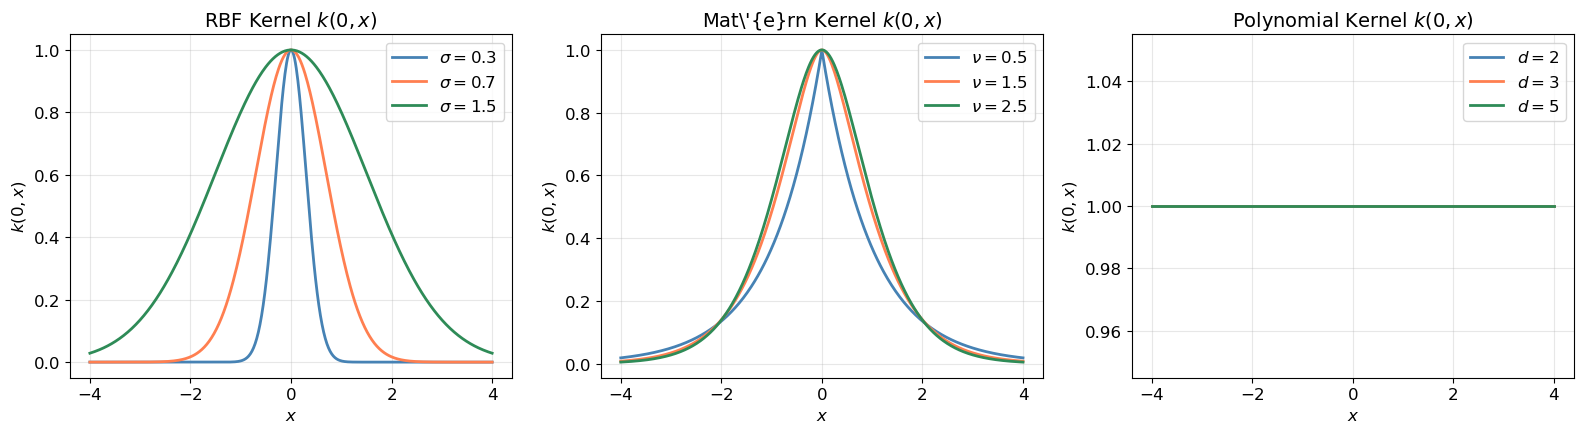

In [4]:
# =============================================================================
#  Visualize kernel functions k(x, .) for a fixed x
# =============================================================================

x_grid = np.linspace(-4, 4, 500).reshape(-1, 1)
x_center = np.array([[0.0]])  # k(0, .)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# --- RBF kernel with varying bandwidth ---
ax = axes[0]
for i, sigma in enumerate([0.3, 0.7, 1.5]):
    k_vals = rbf_kernel(x_center, x_grid, sigma=sigma).ravel()
    ax.plot(x_grid.ravel(), k_vals, color=PALETTE[i], label=rf'$\sigma = {sigma}$')
ax.set_title('RBF Kernel $k(0, x)$')
ax.set_xlabel('$x$')
ax.set_ylabel('$k(0, x)$')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Matern kernel with varying nu ---
ax = axes[1]
for i, nu in enumerate([0.5, 1.5, 2.5]):
    k_vals = matern_kernel(x_center, x_grid, nu=nu, length_scale=1.0).ravel()
    ax.plot(x_grid.ravel(), k_vals, color=PALETTE[i], label=rf'$\nu = {nu}$')
ax.set_title(r'Mat\'{e}rn Kernel $k(0, x)$')
ax.set_xlabel('$x$')
ax.set_ylabel('$k(0, x)$')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Polynomial kernel with varying degree ---
ax = axes[2]
for i, d in enumerate([2, 3, 5]):
    k_vals = polynomial_kernel(x_center, x_grid, degree=d, c=1.0).ravel()
    ax.plot(x_grid.ravel(), k_vals, color=PALETTE[i], label=f'$d = {d}$')
ax.set_title('Polynomial Kernel $k(0, x)$')
ax.set_xlabel('$x$')
ax.set_ylabel('$k(0, x)$')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

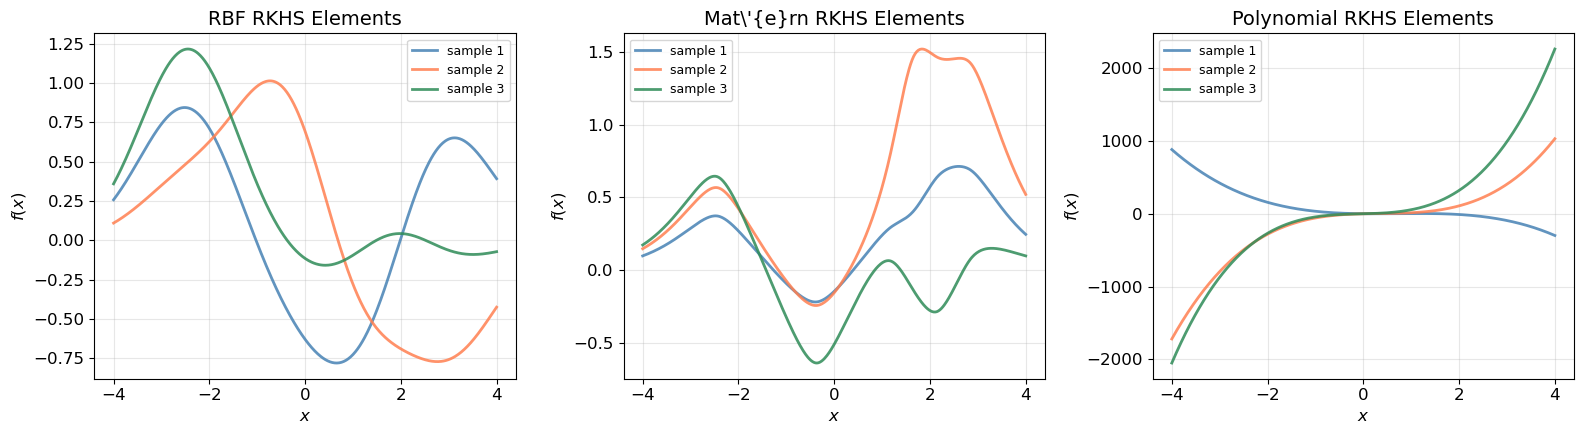

In [5]:
# =============================================================================
#  Representative RKHS elements: random linear combinations of kernel basis
# =============================================================================
#
#  f(x) = sum_i alpha_i * k(x_i, x)
#  These are elements of the RKHS H_k with norm ||f||^2 = alpha^T K alpha

centers = rng.uniform(-3, 3, size=(6, 1))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
titles = ['RBF RKHS Elements', r'Mat\'{e}rn RKHS Elements', 'Polynomial RKHS Elements']
kernels = [
    lambda C, X: rbf_kernel(C, X, sigma=1.0),
    lambda C, X: matern_kernel(C, X, nu=1.5, length_scale=1.0),
    lambda C, X: polynomial_kernel(C, X, degree=3, c=1.0),
]

for ax, title, kern_fn in zip(axes, titles, kernels):
    K_basis = kern_fn(centers, x_grid)  # (6, 500)
    for j in range(3):
        alphas = rng.standard_normal(6)
        f_vals = alphas @ K_basis
        ax.plot(x_grid.ravel(), f_vals, color=PALETTE[j], alpha=0.85,
                label=f'sample {j+1}')
    ax.set_title(title)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$f(x)$')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 2. Mercer's Theorem

### 2.1 Statement

Let $\mathcal{X}$ be a compact subset of $\mathbb{R}^d$ with a finite Borel measure $\mu$. Let $k : \mathcal{X} \times \mathcal{X} \to \mathbb{R}$ be a continuous, symmetric, positive-definite kernel. Define the **integral operator** $T_k : L^2(\mathcal{X}, \mu) \to L^2(\mathcal{X}, \mu)$ by

$$(T_k f)(x) = \int_{\mathcal{X}} k(x, y) f(y) \, d\mu(y).$$

**Mercer's Theorem.** The operator $T_k$ is compact, self-adjoint, and positive. It has a countable set of eigenvalues $\lambda_1 \geq \lambda_2 \geq \cdots \geq 0$ with corresponding orthonormal eigenfunctions $\{\phi_i\}_{i=1}^{\infty}$ in $L^2(\mathcal{X}, \mu)$, and the kernel admits the uniformly convergent expansion

$$k(x, y) = \sum_{i=1}^{\infty} \lambda_i \, \phi_i(x) \, \phi_i(y).$$

### 2.2 Feature Map

Mercer's theorem provides an explicit **feature map** $\varphi : \mathcal{X} \to \ell^2$ defined by

$$\varphi(x) = \left( \sqrt{\lambda_1} \, \phi_1(x), \, \sqrt{\lambda_2} \, \phi_2(x), \, \ldots \right)$$

such that $k(x, y) = \langle \varphi(x), \varphi(y) \rangle_{\ell^2}$.

### 2.3 Nystrom Approximation

In practice, we approximate the integral operator by discretizing: given $m$ sample points $\{z_j\}$, the Gram matrix $K_{ij} = k(z_i, z_j)$ approximates $T_k$. The eigendecomposition $K = V \Lambda V^T$ gives approximate eigenfunctions via the **Nystrom extension**:

$$\hat{\phi}_i(x) = \frac{1}{\hat{\lambda}_i} \sum_{j=1}^{m} v_{ji} \, k(x, z_j)$$

where $\hat{\lambda}_i = \lambda_i / m$ and $v_{ji}$ are elements of the $i$-th eigenvector.

In [6]:
# =============================================================================
#  Nystrom approximation of Mercer's eigendecomposition for the RBF kernel
# =============================================================================

# Discretize [a, b] with m quadrature points
a, b = -5.0, 5.0
m = 200
z = np.linspace(a, b, m).reshape(-1, 1)  # quadrature points
dz = (b - a) / m  # uniform spacing (trapezoid weight)

sigma_mercer = 1.0
K = rbf_kernel(z, z, sigma=sigma_mercer)  # (m, m)

# Approximate the integral operator: T_k ≈ (dz) * K
# Eigenvalues of T_k ≈ dz * eigenvalues of K
eigvals_K, eigvecs_K = np.linalg.eigh(K)

# Sort descending
idx = np.argsort(eigvals_K)[::-1]
eigvals_K = eigvals_K[idx]
eigvecs_K = eigvecs_K[:, idx]

# Eigenvalues of the integral operator
eigvals_T = dz * eigvals_K

# Eigenfunctions evaluated on grid (normalize to approximate L2-orthonormal)
# phi_i(z_j) ≈ v_{ji} / sqrt(dz)
eigfuncs = eigvecs_K / np.sqrt(dz)  # (m, m), column i is phi_i at z points

print(f"Top 10 eigenvalues of T_k: {eigvals_T[:10].round(4)}")
print(f"Sum of eigenvalues: {eigvals_T.sum():.4f}")
print(f"Trace of kernel (k(x,x) integrated): {dz * np.trace(K):.4f}")

Top 10 eigenvalues of T_k: [2.3982 2.1324 1.7544 1.3367 0.9444 0.6198 0.3786 0.2158 0.115  0.0575]
Sum of eigenvalues: 10.0000
Trace of kernel (k(x,x) integrated): 10.0000


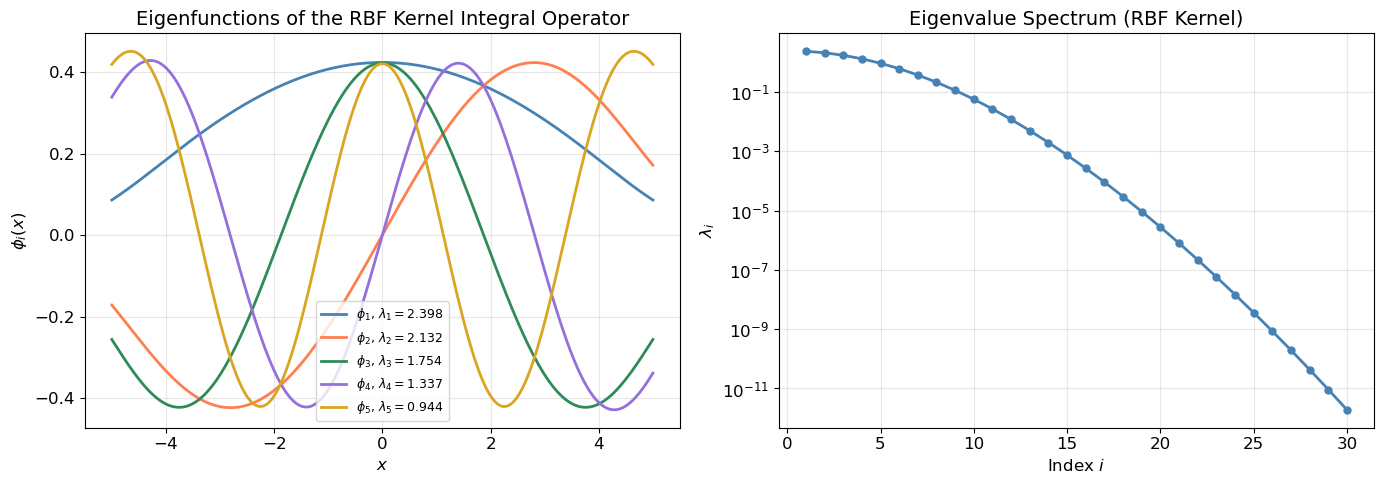

In [7]:
# =============================================================================
#  Visualize eigenfunctions of the RBF kernel
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: first few eigenfunctions
ax = axes[0]
for i in range(5):
    # Flip sign for consistent visualization
    sign = np.sign(eigfuncs[m // 2, i]) if eigfuncs[m // 2, i] != 0 else 1.0
    ax.plot(z.ravel(), sign * eigfuncs[:, i], color=PALETTE[i],
            label=rf'$\phi_{{{i+1}}}$, $\lambda_{{{i+1}}}={eigvals_T[i]:.3f}$')
ax.set_title('Eigenfunctions of the RBF Kernel Integral Operator')
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\phi_i(x)$')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: eigenvalue spectrum
ax = axes[1]
n_show = 30
ax.semilogy(range(1, n_show + 1), eigvals_T[:n_show], 'o-', color=C_PRIMARY, markersize=5)
ax.set_title('Eigenvalue Spectrum (RBF Kernel)')
ax.set_xlabel('Index $i$')
ax.set_ylabel(r'$\lambda_i$')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

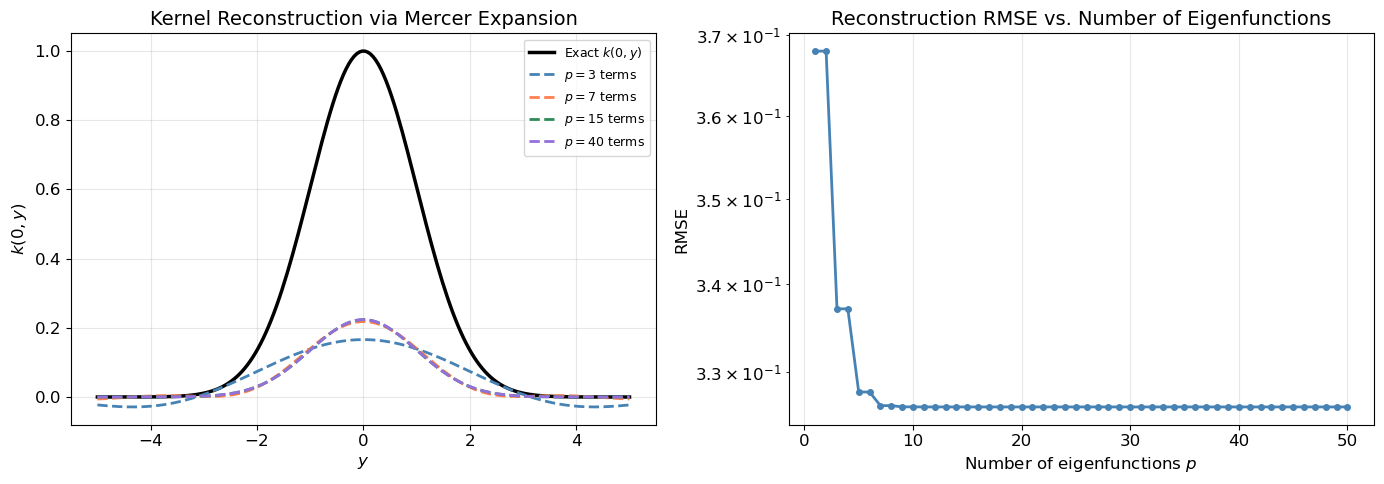

In [8]:
# =============================================================================
#  Kernel reconstruction quality vs. number of eigenfunctions
#  k(x, y) ≈ sum_{i=1}^{p} lambda_i * phi_i(x) * phi_i(y)
# =============================================================================

# Evaluate exact kernel at a test pair
x_test = np.array([[0.0]])
y_test = z  # reconstruct k(0, y) for all y
k_exact = rbf_kernel(x_test, y_test, sigma=sigma_mercer).ravel()

# Nystrom extension: phi_i(x_test) = (1/lambda_i) * sum_j v_{ji} * k(x_test, z_j) * dz
k_xtest_z = rbf_kernel(x_test, z, sigma=sigma_mercer).ravel()  # (m,)
phi_at_xtest = np.zeros(m)
for i in range(m):
    if eigvals_T[i] > 1e-12:
        phi_at_xtest[i] = (dz / eigvals_T[i]) * np.dot(eigvecs_K[:, i], k_xtest_z)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: reconstructed kernel
ax = axes[0]
ax.plot(z.ravel(), k_exact, 'k-', linewidth=2.5, label='Exact $k(0, y)$')
truncations = [3, 7, 15, 40]
for idx_t, p in enumerate(truncations):
    # k_approx(x, y) = sum_{i=1}^{p} lambda_i * phi_i(x) * phi_i(y)
    k_approx = np.zeros(m)
    for i in range(p):
        k_approx += eigvals_T[i] * phi_at_xtest[i] * eigfuncs[:, i]
    ax.plot(z.ravel(), k_approx, '--', color=PALETTE[idx_t % len(PALETTE)],
            label=f'$p = {p}$ terms')
ax.set_title('Kernel Reconstruction via Mercer Expansion')
ax.set_xlabel('$y$')
ax.set_ylabel('$k(0, y)$')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: reconstruction error vs p
ax = axes[1]
p_range = np.arange(1, 51)
errors = []
for p in p_range:
    k_approx = np.zeros(m)
    for i in range(p):
        k_approx += eigvals_T[i] * phi_at_xtest[i] * eigfuncs[:, i]
    err = np.sqrt(np.mean((k_exact - k_approx)**2))
    errors.append(err)
ax.semilogy(p_range, errors, 'o-', color=C_PRIMARY, markersize=4)
ax.set_title('Reconstruction RMSE vs. Number of Eigenfunctions')
ax.set_xlabel('Number of eigenfunctions $p$')
ax.set_ylabel('RMSE')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 3. The Representer Theorem

### 3.1 Statement

**Theorem (Representer Theorem).** Let $\mathcal{H}_k$ be an RKHS with kernel $k$, let $(x_1, y_1), \ldots, (x_n, y_n) \in \mathcal{X} \times \mathbb{R}$ be training data, and consider the regularized empirical risk minimization problem

$$\min_{f \in \mathcal{H}_k} \left[ \sum_{i=1}^n L(y_i, f(x_i)) + \lambda \|f\|_{\mathcal{H}_k}^2 \right]$$

where $L$ is an arbitrary loss function and $\lambda > 0$. Then the minimizer has the form

$$f^*(x) = \sum_{i=1}^n \alpha_i \, k(x_i, x)$$

for some $\alpha_1, \ldots, \alpha_n \in \mathbb{R}$.

### 3.2 Proof Sketch

Decompose any $f \in \mathcal{H}_k$ as $f = f_{\parallel} + f_{\perp}$ where

$$f_{\parallel} \in \text{span}\{k(x_1, \cdot), \ldots, k(x_n, \cdot)\}, \quad f_{\perp} \perp \text{span}\{k(x_1, \cdot), \ldots, k(x_n, \cdot)\}.$$

By the reproducing property, $f(x_i) = \langle f, k(x_i, \cdot)\rangle = f_{\parallel}(x_i)$ since $\langle f_{\perp}, k(x_i, \cdot)\rangle = 0$. So the loss depends only on $f_{\parallel}$. But $\|f\|^2 = \|f_{\parallel}\|^2 + \|f_{\perp}\|^2 \geq \|f_{\parallel}\|^2$, so the regularizer is minimized when $f_{\perp} = 0$.

### 3.3 Kernel Ridge Regression

For squared loss $L(y, \hat{y}) = (y - \hat{y})^2$, the representer theorem gives:

$$\min_{\boldsymbol{\alpha} \in \mathbb{R}^n} \|\mathbf{y} - K\boldsymbol{\alpha}\|^2 + \lambda \boldsymbol{\alpha}^T K \boldsymbol{\alpha}$$

Setting the gradient to zero:

$$\boldsymbol{\alpha}^* = (K + \lambda I)^{-1} \mathbf{y}$$

and the prediction at a new point $x$ is

$$f^*(x) = \sum_{i=1}^n \alpha_i^* \, k(x_i, x) = \mathbf{k}(x)^T (K + \lambda I)^{-1} \mathbf{y}$$

where $\mathbf{k}(x) = [k(x_1, x), \ldots, k(x_n, x)]^T$.

In [9]:
# =============================================================================
#  Kernel Ridge Regression from scratch
# =============================================================================

def kernel_ridge_regression(X_train, y_train, X_test, kernel_fn, lam=1e-2):
    """
    Kernel Ridge Regression.
    Returns predictions at X_test and the weight vector alpha.
    """
    K = kernel_fn(X_train, X_train)  # (n, n)
    n = K.shape[0]
    # Solve (K + lambda I) alpha = y
    A = K + lam * np.eye(n)
    cho = cho_factor(A)
    alpha = cho_solve(cho, y_train)
    # Predict
    K_test = kernel_fn(X_test, X_train)  # (m, n)
    y_pred = K_test @ alpha
    return y_pred, alpha


# --- Generate noisy data from a target function ---
np.random.seed(SEED)
n_train = 20
X_train = rng.uniform(-3, 3, size=(n_train, 1))
X_train = np.sort(X_train, axis=0)
target_fn = lambda x: np.sin(2 * x) + 0.3 * np.cos(5 * x)
noise_std = 0.2
y_train = target_fn(X_train).ravel() + noise_std * rng.standard_normal(n_train)

X_test = np.linspace(-4, 4, 300).reshape(-1, 1)

# --- KRR prediction ---
sigma_krr = 0.8
lam_krr = 1e-2
kern_fn = lambda X, Y: rbf_kernel(X, Y, sigma=sigma_krr)

y_pred_krr, alpha_krr = kernel_ridge_regression(
    X_train, y_train, X_test, kern_fn, lam=lam_krr
)

print(f"KRR coefficients (first 5): {alpha_krr[:5].round(4)}")
print(f"RKHS norm ||f||_H^2 = alpha^T K alpha = {alpha_krr @ kern_fn(X_train, X_train) @ alpha_krr:.4f}")

KRR coefficients (first 5): [-8.5045 11.5898 -6.7816 -3.4273 -9.0293]
RKHS norm ||f||_H^2 = alpha^T K alpha = 9.7190


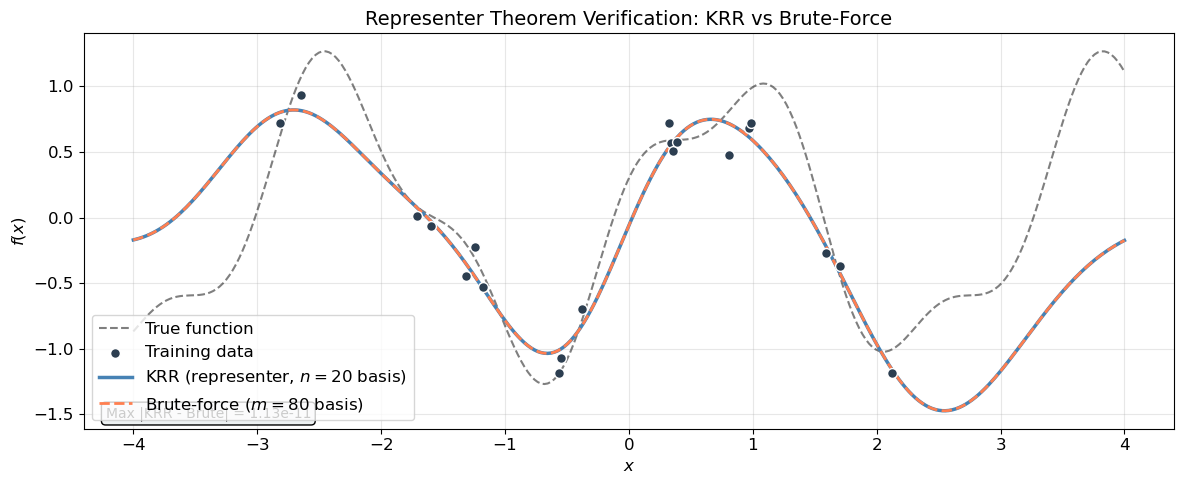


Max absolute difference between KRR and brute-force: 1.13e-11
=> Representer theorem confirmed: solution lies in span of kernel evaluations at training points.


In [10]:
# =============================================================================
#  Verify representer theorem: compare KRR with brute-force search
#  over a discretized function space
# =============================================================================

# Discretize the function space: use a dense set of kernel basis functions
n_basis = 80
X_basis = np.linspace(-4, 4, n_basis).reshape(-1, 1)
K_basis_train = kern_fn(X_basis, X_train)  # (n_basis, n_train)
K_basis_basis = kern_fn(X_basis, X_basis)   # (n_basis, n_basis)
K_train_basis = kern_fn(X_train, X_basis)   # (n_train, n_basis)

# Optimize over the larger basis: min ||y - K_{train,basis} * beta||^2 + lam * beta^T K_{basis,basis} beta
# Gradient: -2 K_{train,basis}^T (y - K_{train,basis} beta) + 2 lam K_{basis,basis} beta = 0
# => (K_{train,basis}^T K_{train,basis} + lam K_{basis,basis}) beta = K_{train,basis}^T y
A_brute = K_train_basis.T @ K_train_basis + lam_krr * K_basis_basis
b_brute = K_train_basis.T @ y_train
beta_brute = np.linalg.solve(A_brute, b_brute)

# Predict on test set from brute-force
K_test_basis = kern_fn(X_test, X_basis)
y_pred_brute = K_test_basis @ beta_brute

# Compare
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.plot(X_test.ravel(), target_fn(X_test).ravel(), 'k--', linewidth=1.5,
        label='True function', alpha=0.5)
ax.scatter(X_train.ravel(), y_train, color=C_DARK, s=50, zorder=5,
           label='Training data', edgecolors='white')
ax.plot(X_test.ravel(), y_pred_krr, color=C_PRIMARY, linewidth=2.5,
        label=f'KRR (representer, $n={n_train}$ basis)')
ax.plot(X_test.ravel(), y_pred_brute, '--', color=C_SECONDARY, linewidth=2,
        label=f'Brute-force ($m={n_basis}$ basis)')
ax.set_title('Representer Theorem Verification: KRR vs Brute-Force')
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.legend()
ax.grid(True, alpha=0.3)

max_diff = np.max(np.abs(y_pred_krr - y_pred_brute))
ax.text(0.02, 0.02, f'Max |KRR - Brute| = {max_diff:.2e}',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor=C_LIGHT))

plt.tight_layout()
plt.show()

print(f"\nMax absolute difference between KRR and brute-force: {max_diff:.2e}")
print("=> Representer theorem confirmed: solution lies in span of kernel evaluations at training points.")

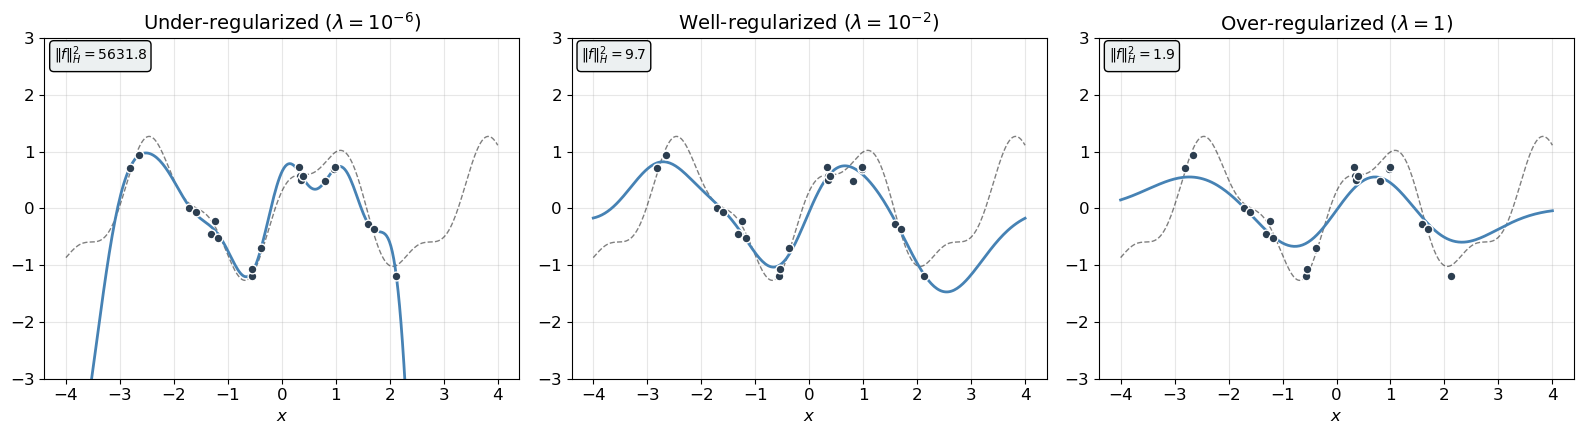

In [11]:
# =============================================================================
#  Effect of regularization on KRR
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
lambdas = [1e-6, 1e-2, 1.0]
titles_lam = [r'Under-regularized ($\lambda=10^{-6}$)',
              r'Well-regularized ($\lambda=10^{-2}$)',
              r'Over-regularized ($\lambda=1$)']

for ax, lam, title in zip(axes, lambdas, titles_lam):
    y_pred, alpha = kernel_ridge_regression(X_train, y_train, X_test, kern_fn, lam=lam)
    rkhs_norm = alpha @ kern_fn(X_train, X_train) @ alpha
    ax.plot(X_test.ravel(), target_fn(X_test).ravel(), 'k--', linewidth=1, alpha=0.5,
            label='True')
    ax.scatter(X_train.ravel(), y_train, color=C_DARK, s=40, zorder=5, edgecolors='white')
    ax.plot(X_test.ravel(), y_pred, color=C_PRIMARY, linewidth=2)
    ax.set_title(title)
    ax.set_xlabel('$x$')
    ax.set_ylim(-3, 3)
    ax.text(0.02, 0.98, rf'$\|f\|_H^2 = {rkhs_norm:.1f}$',
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor=C_LIGHT))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 4. Connection to Gaussian Processes

### 4.1 GP Posterior Mean as RKHS Minimizer

A **Gaussian process** $f \sim \mathcal{GP}(0, k)$ with kernel $k$ defines a prior over functions. Given observations $(X, \mathbf{y})$ with i.i.d. noise $\epsilon \sim \mathcal{N}(0, \sigma_n^2)$, the **GP posterior** is:

$$f | X, \mathbf{y} \sim \mathcal{GP}(\bar{f}, \text{cov}(f))$$

where the posterior mean and covariance are:

$$\bar{f}(x) = \mathbf{k}(x)^T (K + \sigma_n^2 I)^{-1} \mathbf{y}$$

$$\text{cov}(f(x), f(x')) = k(x, x') - \mathbf{k}(x)^T (K + \sigma_n^2 I)^{-1} \mathbf{k}(x')$$

### 4.2 Equivalence

The GP posterior mean $\bar{f}(x)$ is **identical** to the kernel ridge regression solution with $\lambda = \sigma_n^2$:

$$\bar{f}(x) = \mathbf{k}(x)^T (K + \sigma_n^2 I)^{-1} \mathbf{y} = f^*_{\text{KRR}}(x)$$

The KRR solution is also the **MAP estimate** of the GP posterior. However, GPs provide a full posterior distribution over functions, giving natural **uncertainty quantification** that KRR alone does not.

### 4.3 RKHS Norm as Complexity Measure

The RKHS norm $\|f\|_{\mathcal{H}_k}^2 = \boldsymbol{\alpha}^T K \boldsymbol{\alpha}$ corresponds to the negative log-prior probability (up to constants) under the GP:

$$-\log p(f) \propto \|f\|_{\mathcal{H}_k}^2$$

Functions with small RKHS norm are "simple" relative to the kernel and receive high prior probability.

In [12]:
# =============================================================================
#  GP regression vs Kernel Ridge Regression — side-by-side comparison
# =============================================================================

def gp_regression(X_train, y_train, X_test, kernel_fn, noise_var=0.04):
    """
    Gaussian Process regression from scratch.
    Returns posterior mean and variance at X_test.
    """
    K = kernel_fn(X_train, X_train)  # (n, n)
    n = K.shape[0]
    K_noise = K + noise_var * np.eye(n)
    cho = cho_factor(K_noise)
    
    # Posterior mean
    alpha = cho_solve(cho, y_train)  # (K + sigma^2 I)^{-1} y
    K_star = kernel_fn(X_test, X_train)  # (m, n)
    mu = K_star @ alpha
    
    # Posterior variance
    K_star_star = kernel_fn(X_test, X_test)  # (m, m)
    v = cho_solve(cho, K_star.T)  # (n, m)
    var = np.diag(K_star_star) - np.sum(K_star.T * v, axis=0)
    var = np.maximum(var, 0.0)  # numerical stability
    
    return mu, var


# Same data as before; use sigma_n^2 = lambda for equivalence
noise_var = lam_krr  # lambda = sigma_n^2

# GP prediction
mu_gp, var_gp = gp_regression(X_train, y_train, X_test, kern_fn, noise_var=noise_var)
std_gp = np.sqrt(var_gp)

# KRR prediction (already computed)
y_pred_krr_check, _ = kernel_ridge_regression(
    X_train, y_train, X_test, kern_fn, lam=lam_krr
)

print(f"Max |GP mean - KRR prediction|: {np.max(np.abs(mu_gp - y_pred_krr_check)):.2e}")
print("=> GP posterior mean is identical to KRR prediction.")

Max |GP mean - KRR prediction|: 0.00e+00
=> GP posterior mean is identical to KRR prediction.


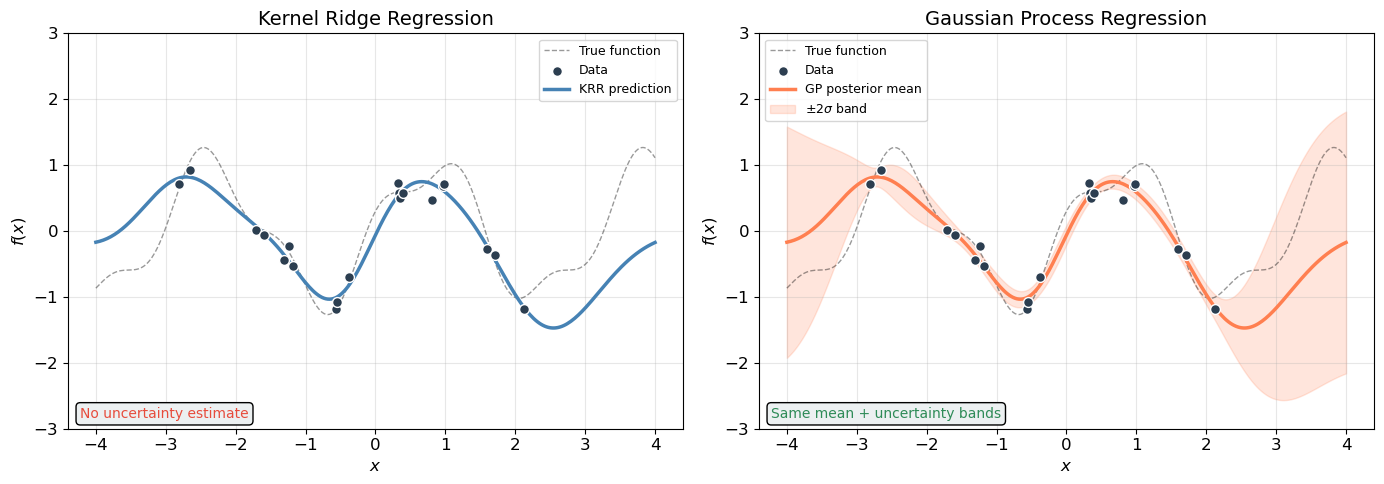

In [13]:
# =============================================================================
#  Visualization: GP vs KRR
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Kernel Ridge Regression ---
ax = axes[0]
ax.plot(X_test.ravel(), target_fn(X_test).ravel(), 'k--', linewidth=1, alpha=0.4,
        label='True function')
ax.scatter(X_train.ravel(), y_train, color=C_DARK, s=50, zorder=5,
           edgecolors='white', label='Data')
ax.plot(X_test.ravel(), y_pred_krr_check, color=C_PRIMARY, linewidth=2.5,
        label='KRR prediction')
ax.set_title('Kernel Ridge Regression')
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_ylim(-3, 3)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.text(0.02, 0.02, 'No uncertainty estimate',
        transform=ax.transAxes, fontsize=10, color=C_ACCENT,
        verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor=C_LIGHT))

# --- Right: Gaussian Process ---
ax = axes[1]
ax.plot(X_test.ravel(), target_fn(X_test).ravel(), 'k--', linewidth=1, alpha=0.4,
        label='True function')
ax.scatter(X_train.ravel(), y_train, color=C_DARK, s=50, zorder=5,
           edgecolors='white', label='Data')
ax.plot(X_test.ravel(), mu_gp, color=C_SECONDARY, linewidth=2.5,
        label='GP posterior mean')
ax.fill_between(X_test.ravel(), mu_gp - 2 * std_gp, mu_gp + 2 * std_gp,
                color=C_SECONDARY, alpha=0.2, label=r'$\pm 2\sigma$ band')
ax.set_title('Gaussian Process Regression')
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_ylim(-3, 3)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.text(0.02, 0.02, 'Same mean + uncertainty bands',
        transform=ax.transAxes, fontsize=10, color=C_TERTIARY,
        verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor=C_LIGHT))

plt.tight_layout()
plt.show()

---

## 5. Kernel Mean Embeddings & Maximum Mean Discrepancy

### 5.1 Kernel Mean Embedding

Given a probability distribution $P$ on $\mathcal{X}$ and a kernel $k$ with RKHS $\mathcal{H}_k$, the **kernel mean embedding** of $P$ is the element $\mu_P \in \mathcal{H}_k$ defined by

$$\mu_P = \mathbb{E}_{x \sim P}[k(x, \cdot)]$$

When $k$ is a **characteristic kernel** (e.g., Gaussian), the embedding is **injective**: $P = Q \iff \mu_P = \mu_Q$.

The embedding satisfies the identity

$$\mathbb{E}_{x \sim P}[f(x)] = \langle f, \mu_P \rangle_{\mathcal{H}_k} \quad \forall f \in \mathcal{H}_k$$

so the mean embedding encodes all information about $P$ that functions in $\mathcal{H}_k$ can detect.

### 5.2 Maximum Mean Discrepancy (MMD)

The **MMD** between two distributions $P$ and $Q$ is:

$$\text{MMD}(P, Q) = \|\mu_P - \mu_Q\|_{\mathcal{H}_k} = \sup_{f \in \mathcal{H}_k, \|f\| \leq 1} \left( \mathbb{E}_P[f] - \mathbb{E}_Q[f] \right)$$

Expanding the squared norm:

$$\text{MMD}^2(P, Q) = \mathbb{E}_{x,x' \sim P}[k(x,x')] - 2\mathbb{E}_{x \sim P, y \sim Q}[k(x,y)] + \mathbb{E}_{y,y' \sim Q}[k(y,y')]$$

### 5.3 Unbiased Estimator

Given i.i.d. samples $\{x_i\}_{i=1}^m \sim P$ and $\{y_j\}_{j=1}^n \sim Q$, the **unbiased estimator** of $\text{MMD}^2$ is:

$$\widehat{\text{MMD}}^2_u = \frac{1}{m(m-1)} \sum_{i \neq j} k(x_i, x_j) - \frac{2}{mn} \sum_{i,j} k(x_i, y_j) + \frac{1}{n(n-1)} \sum_{i \neq j} k(y_i, y_j)$$

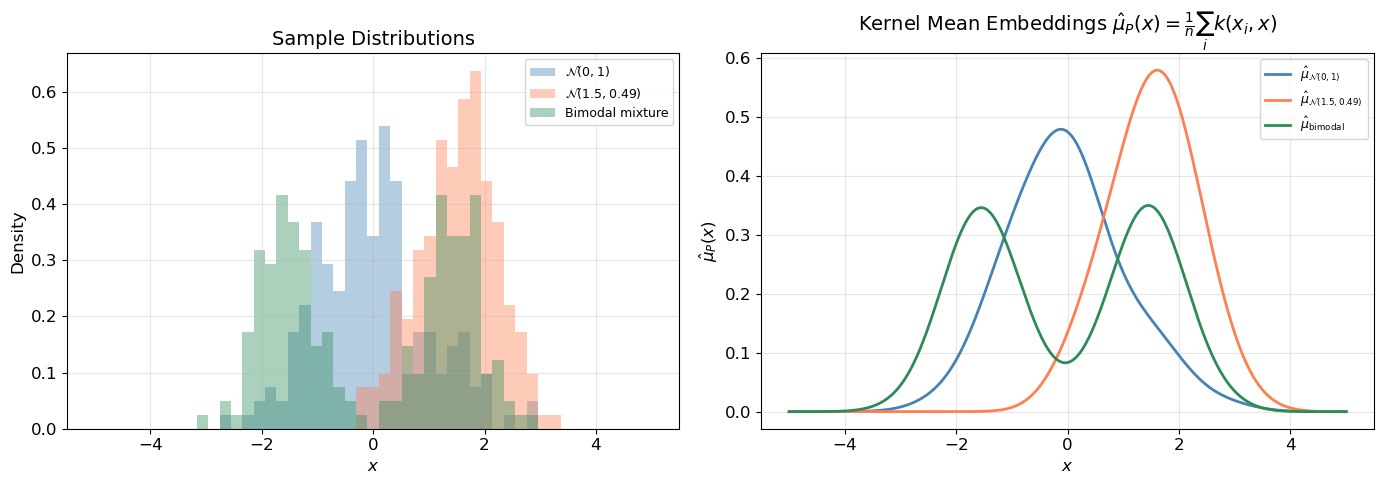

In [14]:
# =============================================================================
#  Kernel Mean Embedding visualization for 1D distributions
# =============================================================================

def empirical_kernel_mean_embedding(samples, x_grid, kernel_fn):
    """
    Compute the empirical kernel mean embedding mu_P(x) = (1/n) sum_i k(x_i, x)
    evaluated at points in x_grid.
    """
    samples = np.atleast_2d(samples)
    x_grid = np.atleast_2d(x_grid)
    K = kernel_fn(x_grid, samples)  # (len(x_grid), len(samples))
    return K.mean(axis=1)


x_grid_embed = np.linspace(-5, 5, 500).reshape(-1, 1)
kern_embed = lambda X, Y: rbf_kernel(X, Y, sigma=0.5)

# Three distributions
n_samp = 200
samples_1 = rng.normal(0, 1, size=(n_samp, 1))           # N(0,1)
samples_2 = rng.normal(1.5, 0.7, size=(n_samp, 1))       # N(1.5, 0.7)
samples_3 = np.concatenate([rng.normal(-1.5, 0.5, (n_samp // 2, 1)),
                            rng.normal(1.5, 0.5, (n_samp // 2, 1))])  # bimodal

embed_1 = empirical_kernel_mean_embedding(samples_1, x_grid_embed, kern_embed)
embed_2 = empirical_kernel_mean_embedding(samples_2, x_grid_embed, kern_embed)
embed_3 = empirical_kernel_mean_embedding(samples_3, x_grid_embed, kern_embed)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: sample histograms
ax = axes[0]
bins = np.linspace(-5, 5, 50)
ax.hist(samples_1.ravel(), bins=bins, density=True, alpha=0.4, color=C_PRIMARY,
        label='$\mathcal{N}(0, 1)$')
ax.hist(samples_2.ravel(), bins=bins, density=True, alpha=0.4, color=C_SECONDARY,
        label='$\mathcal{N}(1.5, 0.49)$')
ax.hist(samples_3.ravel(), bins=bins, density=True, alpha=0.4, color=C_TERTIARY,
        label='Bimodal mixture')
ax.set_title('Sample Distributions')
ax.set_xlabel('$x$')
ax.set_ylabel('Density')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: kernel mean embeddings
ax = axes[1]
ax.plot(x_grid_embed.ravel(), embed_1, color=C_PRIMARY, linewidth=2,
        label=r'$\hat{\mu}_{\mathcal{N}(0,1)}$')
ax.plot(x_grid_embed.ravel(), embed_2, color=C_SECONDARY, linewidth=2,
        label=r'$\hat{\mu}_{\mathcal{N}(1.5, 0.49)}$')
ax.plot(x_grid_embed.ravel(), embed_3, color=C_TERTIARY, linewidth=2,
        label=r'$\hat{\mu}_{\mathrm{bimodal}}$')
ax.set_title(r'Kernel Mean Embeddings $\hat{\mu}_P(x) = \frac{1}{n}\sum_i k(x_i, x)$')
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\hat{\mu}_P(x)$')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# =============================================================================
#  MMD two-sample test implementation
# =============================================================================

def compute_mmd2_unbiased(X, Y, kernel_fn):
    """
    Compute the unbiased estimate of MMD^2 between samples X and Y.
    X: (m, d), Y: (n, d)
    """
    X = np.atleast_2d(X)
    Y = np.atleast_2d(Y)
    m = X.shape[0]
    n = Y.shape[0]
    
    Kxx = kernel_fn(X, X)
    Kyy = kernel_fn(Y, Y)
    Kxy = kernel_fn(X, Y)
    
    # Remove diagonal terms for unbiased estimate
    sum_xx = (Kxx.sum() - np.trace(Kxx)) / (m * (m - 1))
    sum_yy = (Kyy.sum() - np.trace(Kyy)) / (n * (n - 1))
    sum_xy = Kxy.sum() / (m * n)
    
    return sum_xx - 2.0 * sum_xy + sum_yy


def mmd_permutation_test(X, Y, kernel_fn, n_permutations=500):
    """
    MMD two-sample test with permutation-based p-value.
    H0: P = Q
    H1: P != Q
    """
    m = X.shape[0]
    mmd2_observed = compute_mmd2_unbiased(X, Y, kernel_fn)
    
    # Pool samples
    Z = np.vstack([X, Y])
    n_total = Z.shape[0]
    
    mmd2_null = np.zeros(n_permutations)
    for i in range(n_permutations):
        perm = rng.permutation(n_total)
        Z_perm_X = Z[perm[:m]]
        Z_perm_Y = Z[perm[m:]]
        mmd2_null[i] = compute_mmd2_unbiased(Z_perm_X, Z_perm_Y, kernel_fn)
    
    p_value = np.mean(mmd2_null >= mmd2_observed)
    return mmd2_observed, mmd2_null, p_value


print("MMD test functions defined.")

MMD test functions defined.


In [16]:
# =============================================================================
#  Experiment 1: Two clearly different distributions
#  N(0, 1) vs N(0.5, 1) — shifted mean
# =============================================================================

n_test = 150
kern_mmd = lambda X, Y: rbf_kernel(X, Y, sigma=1.0)

X_p = rng.normal(0.0, 1.0, (n_test, 1))
Y_q = rng.normal(0.5, 1.0, (n_test, 1))

mmd2_obs_1, mmd2_null_1, p_val_1 = mmd_permutation_test(X_p, Y_q, kern_mmd, n_permutations=500)

print(f"Test 1: N(0,1) vs N(0.5,1)")
print(f"  MMD^2 observed = {mmd2_obs_1:.6f}")
print(f"  p-value        = {p_val_1:.4f}")
print(f"  Reject H0 at 5%? {'Yes' if p_val_1 < 0.05 else 'No'}")

Test 1: N(0,1) vs N(0.5,1)
  MMD^2 observed = 0.038049
  p-value        = 0.0000
  Reject H0 at 5%? Yes


In [17]:
# =============================================================================
#  Experiment 2: Same distribution — N(0,1) vs N(0,1)
# =============================================================================

X_same_1 = rng.normal(0.0, 1.0, (n_test, 1))
X_same_2 = rng.normal(0.0, 1.0, (n_test, 1))

mmd2_obs_2, mmd2_null_2, p_val_2 = mmd_permutation_test(X_same_1, X_same_2, kern_mmd, n_permutations=500)

print(f"Test 2: N(0,1) vs N(0,1)")
print(f"  MMD^2 observed = {mmd2_obs_2:.6f}")
print(f"  p-value        = {p_val_2:.4f}")
print(f"  Reject H0 at 5%? {'Yes' if p_val_2 < 0.05 else 'No'}")

Test 2: N(0,1) vs N(0,1)
  MMD^2 observed = -0.004831
  p-value        = 0.9380
  Reject H0 at 5%? No


In [18]:
# =============================================================================
#  Experiment 3: Same mean & variance but different shape
#  N(0, 1) vs Laplace(0, 1/sqrt(2))  — both have mean=0, var=1
#  MMD detects this while mean/variance comparisons fail
# =============================================================================

X_gauss = rng.normal(0.0, 1.0, (n_test, 1))
# Laplace with loc=0, scale=1/sqrt(2) has variance = 2*(1/sqrt(2))^2 = 1
Y_laplace = rng.laplace(0.0, 1.0 / np.sqrt(2), (n_test, 1))

mmd2_obs_3, mmd2_null_3, p_val_3 = mmd_permutation_test(X_gauss, Y_laplace, kern_mmd, n_permutations=500)

print(f"Test 3: N(0,1) vs Laplace(0, 1/sqrt(2))  [same mean=0, same var=1]")
print(f"  Sample means:     {X_gauss.mean():.4f} vs {Y_laplace.mean():.4f}")
print(f"  Sample variances: {X_gauss.var():.4f} vs {Y_laplace.var():.4f}")
print(f"  MMD^2 observed  = {mmd2_obs_3:.6f}")
print(f"  p-value         = {p_val_3:.4f}")
print(f"  Reject H0 at 5%? {'Yes' if p_val_3 < 0.05 else 'No'}")
print("  => MMD detects distributional differences beyond mean and variance.")

Test 3: N(0,1) vs Laplace(0, 1/sqrt(2))  [same mean=0, same var=1]
  Sample means:     0.1780 vs -0.0034
  Sample variances: 0.8670 vs 0.8214
  MMD^2 observed  = 0.008524
  p-value         = 0.0480
  Reject H0 at 5%? Yes
  => MMD detects distributional differences beyond mean and variance.


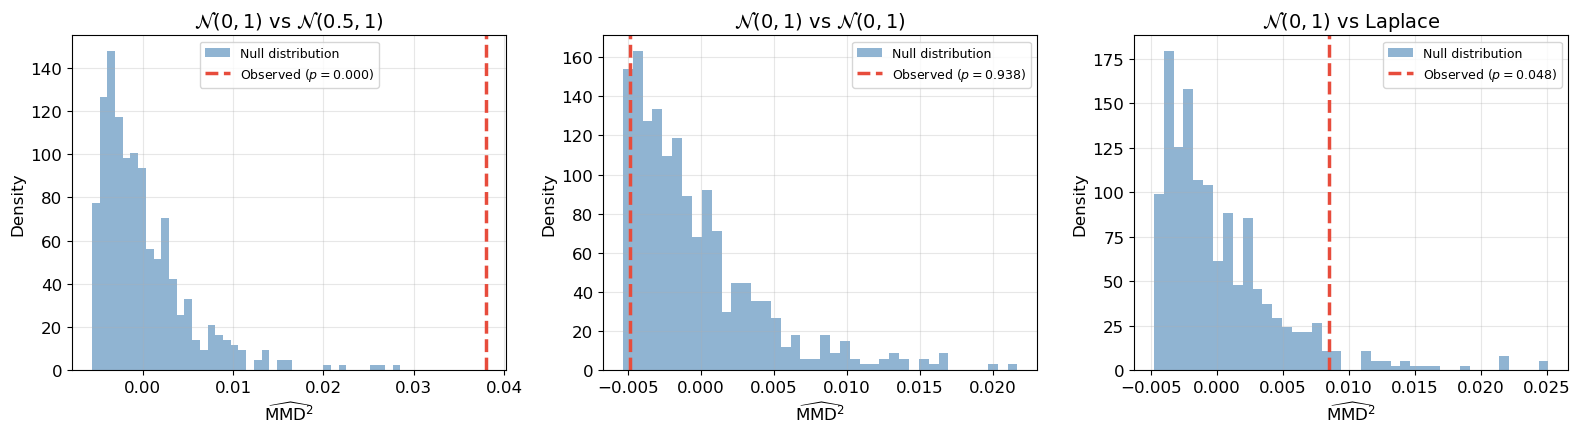

In [19]:
# =============================================================================
#  Visualize null distributions and observed MMD for all three tests
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
tests = [
    (mmd2_null_1, mmd2_obs_1, p_val_1, '$\mathcal{N}(0,1)$ vs $\mathcal{N}(0.5,1)$'),
    (mmd2_null_2, mmd2_obs_2, p_val_2, '$\mathcal{N}(0,1)$ vs $\mathcal{N}(0,1)$'),
    (mmd2_null_3, mmd2_obs_3, p_val_3, '$\mathcal{N}(0,1)$ vs Laplace'),
]

for ax, (null_dist, obs, pv, title) in zip(axes, tests):
    ax.hist(null_dist, bins=40, density=True, color=C_PRIMARY, alpha=0.6,
            label='Null distribution')
    ax.axvline(obs, color=C_ACCENT, linewidth=2.5, linestyle='--',
               label=f'Observed ($p={pv:.3f}$)')
    ax.set_title(title)
    ax.set_xlabel('$\\widehat{\\mathrm{MMD}}^2$')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 6. Infinite-Dimensional Optimization in RKHS

### 6.1 Functional Gradient Descent

Consider the optimization problem in an RKHS $\mathcal{H}_k$:

$$\min_{f \in \mathcal{H}_k} J[f] = \int_{\mathcal{X}} (f(x) - g(x))^2 \, d\mu(x) + \lambda \|f\|_{\mathcal{H}_k}^2$$

where $g$ is a target function and $\mu$ is a measure on $\mathcal{X}$ (in practice, approximated by quadrature or sample points).

### 6.2 Functional Gradient

The **functional gradient** (Frechet derivative) of $J$ at $f$ in direction $h \in \mathcal{H}_k$ is:

$$DJ[f](h) = 2\int_{\mathcal{X}} (f(x) - g(x)) h(x) \, d\mu(x) + 2\lambda \langle f, h \rangle_{\mathcal{H}_k}$$

By the Riesz representation theorem, the gradient $\nabla_{\mathcal{H}} J[f] \in \mathcal{H}_k$ satisfies $DJ[f](h) = \langle \nabla_{\mathcal{H}} J[f], h \rangle_{\mathcal{H}}$ for all $h$. Using the reproducing property, if we discretize $\mu$ at points $\{x_j\}$ with weights $\{w_j\}$:

$$\nabla_{\mathcal{H}} J[f] = 2 \sum_j w_j (f(x_j) - g(x_j)) k(x_j, \cdot) + 2\lambda f$$

### 6.3 Update Rule

The RKHS gradient descent update is:

$$f_{t+1} = f_t - \eta \, \nabla_{\mathcal{H}} J[f_t]$$

Since each iterate is a linear combination of kernel evaluations, the representer theorem structure is maintained. By induction, if $f_0 = 0$:

$$f_t(\cdot) = \sum_j \beta_j^{(t)} k(x_j, \cdot)$$

and the update becomes a finite-dimensional coefficient update:

$$\boldsymbol{\beta}^{(t+1)} = (1 - 2\eta\lambda) \boldsymbol{\beta}^{(t)} - 2\eta \, W \circ (K \boldsymbol{\beta}^{(t)} - \mathbf{g})$$

where $K_{ij} = k(x_i, x_j)$, $\mathbf{g}_j = g(x_j)$, and $W = \text{diag}(w_j)$.

In [20]:
# =============================================================================
#  Functional optimization in RKHS via kernel gradient descent
# =============================================================================

# Target function
target_opt = lambda x: np.sin(2 * x) + 0.5 * np.cos(4 * x)

# Discretization points (quadrature)
n_quad = 60
x_quad = np.linspace(-3, 3, n_quad).reshape(-1, 1)
w_quad = (6.0 / n_quad) * np.ones(n_quad)  # uniform weights
g_vals = target_opt(x_quad).ravel()

# Kernel setup
sigma_opt = 0.6
lam_opt = 0.01
K_quad = rbf_kernel(x_quad, x_quad, sigma=sigma_opt)

# Gradient descent in coefficient space
eta = 0.05  # learning rate
n_iters = 300
beta = np.zeros(n_quad)

# Store snapshots
snapshots_iters = [0, 5, 20, 50, 100, 299]
snapshots = {}
losses = []

for t in range(n_iters):
    # Current function values at quadrature points: f(x_j) = sum_i beta_i k(x_i, x_j)
    f_vals = K_quad @ beta
    
    # Residual
    residual = f_vals - g_vals
    
    # Loss: integral of (f-g)^2 + lambda * ||f||^2
    data_fit = np.sum(w_quad * residual**2)
    rkhs_norm_sq = beta @ K_quad @ beta
    loss = data_fit + lam_opt * rkhs_norm_sq
    losses.append(loss)
    
    if t in snapshots_iters:
        snapshots[t] = beta.copy()
    
    # Gradient update: beta <- (1-2*eta*lam)*beta - 2*eta * diag(w) * (K*beta - g)
    grad_data = w_quad * residual  # element-wise
    beta = (1 - 2 * eta * lam_opt) * beta - 2 * eta * grad_data

# Store final
if (n_iters - 1) in snapshots_iters:
    pass  # already stored

print(f"Initial loss: {losses[0]:.4f}")
print(f"Final loss:   {losses[-1]:.6f}")

Initial loss: 3.8169
Final loss:   0.133560


In [21]:
# =============================================================================
#  Closed-form KRR solution for comparison
# =============================================================================

# Using quadrature points as both "training" and evaluation points,
# and target values as labels, solve the regularized least-squares:
# min ||g - K*beta||^2_W + lam * beta^T K beta
#
# With uniform weights, this simplifies to the standard KRR form.
# For weighted case: (W K^T K + lam K) beta = W K^T g
# => (diag(w) K + lam I) beta = diag(w) g  [since K is symmetric]
#
# Equivalently, the direct KRR: alpha = (K + lam_eff I)^{-1} g
# where lam_eff accounts for the quadrature weight.

W = np.diag(w_quad)
A_cf = W @ K_quad + lam_opt * np.eye(n_quad)
beta_cf = np.linalg.solve(A_cf, W @ g_vals)
f_cf = K_quad @ beta_cf

print(f"Closed-form loss: {np.sum(w_quad * (f_cf - g_vals)**2) + lam_opt * beta_cf @ K_quad @ beta_cf:.6f}")
print(f"Grad descent loss (final): {losses[-1]:.6f}")

Closed-form loss: 0.128634
Grad descent loss (final): 0.133560


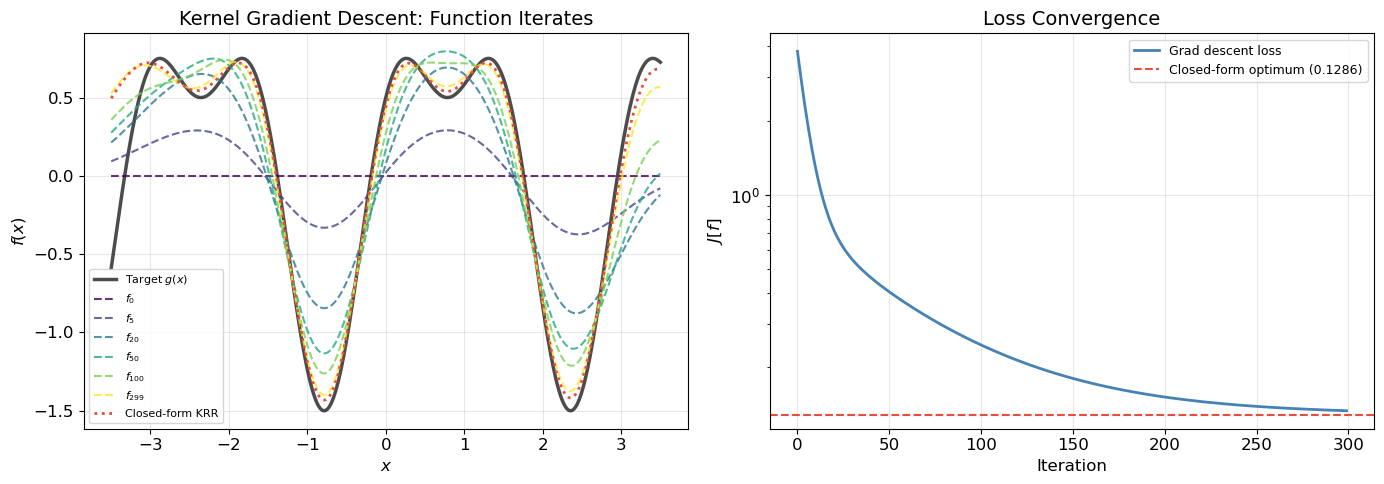

In [22]:
# =============================================================================
#  Visualize convergence of function iterates
# =============================================================================

x_plot = np.linspace(-3.5, 3.5, 400).reshape(-1, 1)
K_plot = rbf_kernel(x_plot, x_quad, sigma=sigma_opt)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: function snapshots
ax = axes[0]
ax.plot(x_plot.ravel(), target_opt(x_plot).ravel(), 'k-', linewidth=2.5,
        label='Target $g(x)$', alpha=0.7)

cmap_iter = cm.viridis
for idx, t in enumerate(snapshots_iters):
    frac = idx / max(len(snapshots_iters) - 1, 1)
    f_snap = K_plot @ snapshots[t]
    ax.plot(x_plot.ravel(), f_snap, '--', color=cmap_iter(frac), linewidth=1.5,
            label=f'$f_{{{t}}}$', alpha=0.8)

# Closed-form solution
f_cf_plot = K_plot @ beta_cf
ax.plot(x_plot.ravel(), f_cf_plot, ':', color=C_ACCENT, linewidth=2,
        label='Closed-form KRR')

ax.set_title('Kernel Gradient Descent: Function Iterates')
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.legend(fontsize=8, loc='lower left')
ax.grid(True, alpha=0.3)

# Right: loss convergence
ax = axes[1]
ax.semilogy(range(n_iters), losses, color=C_PRIMARY, linewidth=2, label='Grad descent loss')
cf_loss = np.sum(w_quad * (f_cf - g_vals)**2) + lam_opt * beta_cf @ K_quad @ beta_cf
ax.axhline(cf_loss, color=C_ACCENT, linestyle='--', linewidth=1.5,
           label=f'Closed-form optimum ({cf_loss:.4f})')
ax.set_title('Loss Convergence')
ax.set_xlabel('Iteration')
ax.set_ylabel('$J[f]$')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# =============================================================================
#  RKHS norm evolution during gradient descent
# =============================================================================

# Recompute norms for stored snapshots
print("RKHS norm ||f_t||_H^2 at selected iterations:")
print("-" * 40)
for t in snapshots_iters:
    b = snapshots[t]
    norm_sq = b @ K_quad @ b
    f_v = K_quad @ b
    data_term = np.sum(w_quad * (f_v - g_vals)**2)
    print(f"  t = {t:3d}:  ||f||_H^2 = {norm_sq:8.4f},  data_fit = {data_term:8.4f}")

norm_cf = beta_cf @ K_quad @ beta_cf
data_cf = np.sum(w_quad * (f_cf - g_vals)**2)
print(f"  Closed-form: ||f||_H^2 = {norm_cf:8.4f},  data_fit = {data_cf:8.4f}")

RKHS norm ||f_t||_H^2 at selected iterations:
----------------------------------------
  t =   0:  ||f||_H^2 =   0.0000,  data_fit =   3.8169
  t =   5:  ||f||_H^2 =   0.4507,  data_fit =   2.0565
  t =  20:  ||f||_H^2 =   2.6730,  data_fit =   0.6891
  t =  50:  ||f||_H^2 =   4.6708,  data_fit =   0.3582
  t = 100:  ||f||_H^2 =   6.4302,  data_fit =   0.1824
  t = 299:  ||f||_H^2 =  10.3548,  data_fit =   0.0300
  Closed-form: ||f||_H^2 =  11.6248,  data_fit =   0.0124


---

## Summary

| Concept | Key Idea |
|---|---|
| **RKHS** | Hilbert space where point evaluation is continuous; uniquely determined by a positive-definite kernel |
| **Mercer's Theorem** | Spectral decomposition $k(x,y) = \sum_i \lambda_i \phi_i(x)\phi_i(y)$; provides explicit feature maps |
| **Representer Theorem** | Regularized ERM solutions lie in span of $n$ kernel evaluations at training points |
| **GP Connection** | GP posterior mean = KRR solution; RKHS norm = negative log-prior; GPs add uncertainty |
| **Kernel Mean Embeddings** | Distributions mapped to RKHS elements; MMD as nonparametric distributional distance |
| **RKHS Optimization** | Functional gradients preserve representer structure; iterates converge to closed-form solution |

---

## References

1. **Berlinet, A. and Thomas-Agnan, C.** (2004). *Reproducing Kernel Hilbert Spaces in Probability and Statistics*. Kluwer Academic Publishers.

2. **Scholkopf, B. and Smola, A.** (2002). *Learning with Kernels: Support Vector Machines, Regularization, Optimization, and Beyond*. MIT Press.

3. **Steinwart, I. and Christmann, A.** (2008). *Support Vector Machines*. Springer.

4. **Rasmussen, C.E. and Williams, C.K.I.** (2006). *Gaussian Processes for Machine Learning*. MIT Press. Available at [gaussianprocess.org/gpml](http://www.gaussianprocess.org/gpml/).

5. **Gretton, A., Borgwardt, K.M., Rasch, M.J., Scholkopf, B., and Smola, A.** (2012). A Kernel Two-Sample Test. *Journal of Machine Learning Research*, 13, 723-773.

6. **Muandet, K., Fukumizu, K., Sriperumbudur, B., and Scholkopf, B.** (2017). Kernel Mean Embedding of Distributions: A Review and Beyond. *Foundations and Trends in Machine Learning*, 10(1-2), 1-141.

7. **Wahba, G.** (1990). *Spline Models for Observational Data*. SIAM.

8. **Aronszajn, N.** (1950). Theory of Reproducing Kernels. *Transactions of the American Mathematical Society*, 68(3), 337-404.

9. **Williams, C.K.I. and Seeger, M.** (2001). Using the Nystrom Method to Speed Up Kernel Machines. *Advances in Neural Information Processing Systems*, 13.